# Tuberculosis (TB) Patient Data — Exploratory Data Analysis (EDA)

**Dataset:** TB patient records from 4 health facilities in Baguio City, Philippines (2016–2025)  
**Facilities:** Pacdal Health Center, Campo Filipino Health Center, Engineer's Hill Health Center, Scout Barrio Health Center  
**Total Files:** 14 CSV files

## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")

Libraries loaded.


## 2. Load & Combine All CSV Files

In [6]:
DATA_DIR = r'dataset'

file_info = {
    'RAW DATA -  PACDAL 2022 (DONE).csv': ('Pacdal', 2022),
    'RAW DATA - Campo Filipino - 2024 (Done).csv': ('Campo Filipino', 2024),
    'RAW DATA - Campo Filipino - 2025 (Done excl. DR).csv': ('Campo Filipino', 2025),
    'RAW DATA - Eng Hill - 2023 A (done).csv': ("Engineer's Hill", 2023),
    'RAW DATA - Eng Hill - 2023 B (done).csv': ("Engineer's Hill", 2023),
    'RAW DATA - Eng Hill - 2025 (done).csv': ("Engineer's Hill", 2025),
    'RAW DATA - Pacdal - 2017 (DONE).csv': ('Pacdal', 2017),
    'RAW DATA - Pacdal - 2018 (DONE).csv': ('Pacdal', 2018),
    'RAW DATA - Pacdal - 2020 (DONE).csv': ('Pacdal', 2020),
    'RAW DATA - Pacdal - 2021 (DONE).csv': ('Pacdal', 2021),
    'RAW DATA - Pacdal - 2024 (DONE).csv': ('Pacdal', 2024),
    'RAW DATA - Pacdal-2016(done).csv': ('Pacdal', 2016),
    'RAW DATA - Scout Barrio - 2021 (Done).csv': ('Scout Barrio', 2021),
    'RAW DATA - Scout Barrio - 2022 (Done).csv': ('Scout Barrio', 2022),
}

MONTHLY_SUBS = ['Monthly Doses Taken','Cumulative Doses Taken','Monthly Missed Doses',
                '%Adherence','Weight','Height','Smear/TB Lamp','Xpert MTB/RIF']

all_dfs = []
for fname, (facility, year) in file_info.items():
    raw = pd.read_csv(os.path.join(DATA_DIR, fname), header=None, dtype=str, encoding='utf-8-sig')
    headers = raw.iloc[0].tolist()
    data = raw.iloc[2:].reset_index(drop=True)

    # Find where monthly data starts
    m0 = next((i for i, h in enumerate(headers) if str(h).strip() == 'Month 0'), None)

    # Core columns
    if m0:
        core = data.iloc[:, :m0].copy()
        core.columns = [str(h).strip() if pd.notna(h) else f'col_{i}' for i, h in enumerate(headers[:m0])]
    else:
        core = data.copy()
        core.columns = [str(h).strip() if pd.notna(h) else f'col_{i}' for i, h in enumerate(headers)]

    # Monthly columns
    if m0:
        mdata = data.iloc[:, m0:]
        ns = len(MONTHLY_SUBS)
        for mi in range(mdata.shape[1] // ns):
            sl = mdata.iloc[:, mi*ns:(mi+1)*ns]
            sl.columns = [f'M{mi}_{s}' for s in MONTHLY_SUBS]
            for c in sl.columns:
                core[c] = sl[c].values

    core['Source_File'] = fname
    core['Facility'] = facility
    core['Data_Year'] = year
    all_dfs.append(core)
    print(f"  {fname}: {len(core)} records")

df = pd.concat(all_dfs, ignore_index=True, sort=False)

# Replace common "N/A" strings with actual NaN
na_strings = ['N/A','n/a','NA','na','None','none','N/a','']
for c in df.columns:
    df[c] = df[c].apply(lambda x: np.nan if pd.notna(x) and str(x).strip() in na_strings else x)

# Convert Age to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

print(f"\n✅ Combined: {df.shape[0]} patients × {df.shape[1]} columns")

  RAW DATA -  PACDAL 2022 (DONE).csv: 34 records
  RAW DATA - Campo Filipino - 2024 (Done).csv: 12 records
  RAW DATA - Campo Filipino - 2025 (Done excl. DR).csv: 6 records
  RAW DATA - Eng Hill - 2023 A (done).csv: 14 records
  RAW DATA - Eng Hill - 2023 B (done).csv: 17 records
  RAW DATA - Eng Hill - 2025 (done).csv: 20 records
  RAW DATA - Pacdal - 2017 (DONE).csv: 15 records
  RAW DATA - Pacdal - 2018 (DONE).csv: 16 records
  RAW DATA - Pacdal - 2020 (DONE).csv: 14 records
  RAW DATA - Pacdal - 2021 (DONE).csv: 16 records
  RAW DATA - Pacdal - 2024 (DONE).csv: 16 records
  RAW DATA - Pacdal-2016(done).csv: 8 records
  RAW DATA - Scout Barrio - 2021 (Done).csv: 5 records
  RAW DATA - Scout Barrio - 2022 (Done).csv: 12 records

✅ Combined: 205 patients × 151 columns


In [7]:
# Save consolidated dataset to CSV
output_path = os.path.join('dataset', 'combined_dataset.csv')
df.to_csv(output_path, index=False)
print(f" dataset saved to: {output_path}")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")

 dataset saved to: dataset\combined_dataset.csv
   Shape: 205 rows × 151 columns


## 3. Dataset Overview

Shape, column names, data types, and records per facility/year.

In [8]:
print(f"Total records : {df.shape[0]}")
print(f"Total columns : {df.shape[1]}")

# Separate core vs monthly column names
core_cols = [c for c in df.columns if not re.match(r'^M\d+_', c)]
monthly_cols = [c for c in df.columns if re.match(r'^M\d+_', c)]
print(f"Core columns  : {len(core_cols)}")
print(f"Monthly cols  : {len(monthly_cols)}")

print("\n--- Core column names ---")
for c in core_cols:
    print(f"  {c}")

print(f"\n--- Records per Facility ---")
print(df['Facility'].value_counts().to_string())

print(f"\n--- Records per Year ---")
print(df['Data_Year'].value_counts().sort_index().to_string())

Total records : 205
Total columns : 151
Core columns  : 47
Monthly cols  : 104

--- Core column names ---
  No.
  Name of Diagnosing Facility
  Date of Birth
  Age
  Sex
  Civil Status
  Nationality?
  Chest X-ray at Case Notification
  Tuberculin skin test
  Xpert MTB/RIF
  Smear Microscopy
  Tuberculosis Culture
  Other Lab. Test
  Date of Diagnosis
  Date of Notification
  Diagnosis
  Bacteriologic Status
  Case Registration Group
  Drug Resistance Bacteriological Status
  Height
  Weight
  Blood Pressure
  Heart Rate
  Respiratory Rate
  Temperature
  O2 Sat
  Prior History of TB
  Name of Treatment Unit
  Treatment Regimen
  Outcome
  Date of Outcome
  Co-morbidities
  Treatment Start Date
  Regimen Type at Start of Treatment
  Regimen Type at 6th month of treatment
  Regimen Type at End of Treatment
  DAT-supported
  Intensive Phase Start Date
  Intensive Phase End Date
  Continuation Phase Start Date
  Continuation Phase End Date
  Source_File
  Facility
  Data_Year
  OTHERS:
  

In [9]:
# Preview first rows
display(df[core_cols].head(10))

,No.,Name of Diagnosing Facility,Date of Birth,Age,Sex,Civil Status,Nationality?,Chest X-ray at Case Notification,Tuberculin skin test,Xpert MTB/RIF,...,Intensive Phase Start Date,Intensive Phase End Date,Continuation Phase Start Date,Continuation Phase End Date,Source_File,Facility,Data_Year,OTHERS:,DAT- supported,Risk Factor/s for Drug Resistance-Tuberculosis
0,1411-011-5-2-022,Pacdal Health Center,5/24/1958,64.0,Male,Married,Filipino,NaN,NaN,MTB not detected,...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN
1,1411-011–22-013,Pacdal Health Center,11/7/1959,62.0,Male,Single,Filipino,Consider PTB,NaN,MTB not detected,...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN
2,1411-011-5-019,Pacdal Health Center,7/7/1988,33.0,Male,Single,Filipino,NaN,NaN,MTB Detected,...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN
3,1411-011-5-22-020,Pacdal Health Center,3/14/1947,75.0,Male,Married,Filipino,NaN,NaN,MTB Detected,...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN
4,1411-011-5-22-016,Pacdal Health Center,9/2/1972,49.0,Female,Married,Filipino,"PTB, both lungs",NaN,MTB Detected,...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN
5,1411-011-5-22-015,Pacdal Health Center,9/8/1959,62.0,Male,Married,Filipino,NaN,NaN,"MTB detected , RIFAM BFS not detected",...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN
6,7,Pacdal Health Center,2/18/1959,65.0,Male,Married,Filipino,Koch's density upper left lobe,NaN,MTB not detected,...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN
7,1411-011-5-22-024,Pacdal Health Center,7/30/1999,23.0,Female,Single,Filipino,Parenchymal Lung Disease Likely Cavity Pulmona...,NaN,MTB detected,...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN
8,9,Pacdal Health Center,12/26/1999,22.0,Male,Single,Filipino,"Very minimal pleural effusion, Left",NaN,MTB not detected,...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN
9,10,Pacdal Health Center,4/20/1999,23.0,Male,Single,Filipino,"Minimal PTB, Right upper lobe , Activity undet...",NaN,MTB not detected,...,NaN,NaN,NaN,NaN,RAW DATA - PACDAL 2022 (DONE).csv,Pacdal,2022,NaN,NaN,NaN


## 4. Missing Values Analysis

In [10]:
# Missing values for core columns
core_analysis = [c for c in core_cols if c not in ['Source_File','Facility','Data_Year']]
miss_count = df[core_analysis].isnull().sum()
miss_pct   = (miss_count / len(df) * 100).round(1)
present    = len(df) - miss_count

miss_summary = pd.DataFrame({
    'Present': present,
    'Missing': miss_count,
    'Missing %': miss_pct
}).sort_values('Missing %', ascending=False)

print(f"Total records: {len(df)}\n")
display(miss_summary)

Total records: 205



,Present,Missing,Missing %
Risk Factor/s for Drug Resistance-Tuberculosis,0,205,100.0
Tuberculosis Culture,1,204,99.5
Other Lab. Test,1,204,99.5
OTHERS:,2,203,99.0
Tuberculin skin test,4,201,98.0
DAT-supported,6,199,97.1
DAT- supported,23,182,88.8
Smear Microscopy,27,178,86.8
Prior History of TB,31,174,84.9
O2 Sat,31,174,84.9


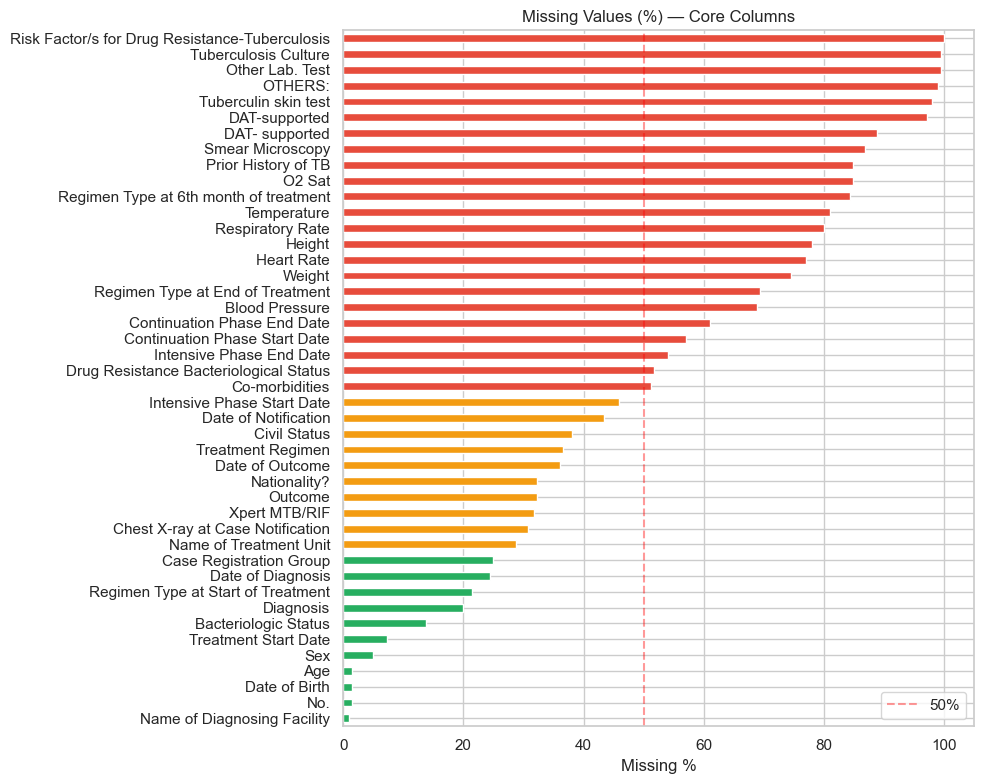

In [11]:
# Bar chart of missing percentages
fig, ax = plt.subplots(figsize=(10, 8))
miss_pct_sorted = miss_pct.sort_values(ascending=True)
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 25 else '#27ae60' for v in miss_pct_sorted]
miss_pct_sorted.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values (%) — Core Columns')
ax.axvline(x=50, color='red', ls='--', alpha=0.4, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

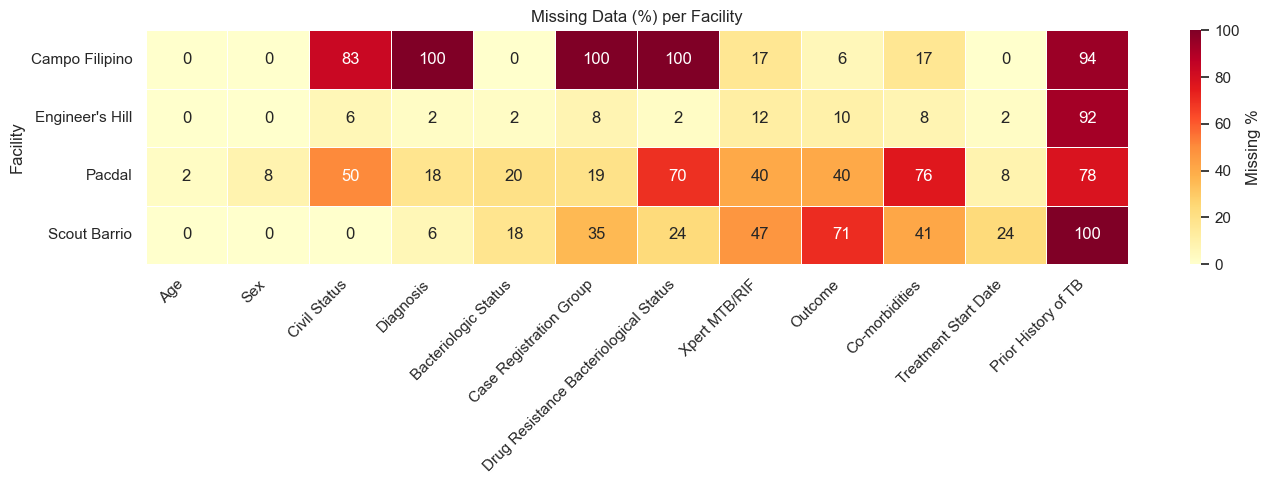

In [12]:
# Missing values heatmap by Facility 
key_clinical = ['Age','Sex','Civil Status','Diagnosis','Bacteriologic Status',
                'Case Registration Group','Drug Resistance Bacteriological Status',
                'Xpert MTB/RIF','Outcome','Co-morbidities','Treatment Start Date',
                'Prior History of TB']
key_clinical = [c for c in key_clinical if c in df.columns]

miss_by_fac = df.groupby('Facility')[key_clinical].apply(lambda x: (x.isnull().mean()*100).round(1))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(miss_by_fac, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=.5, cbar_kws={'label': 'Missing %'})
ax.set_title('Missing Data (%) per Facility')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Descriptive Statistics (Numerical Features)

In [13]:
# Convert monthly numeric columns
for m in range(13):
    for sub in ['Monthly Doses Taken','Cumulative Doses Taken','Monthly Missed Doses','Weight','Height']:
        col = f'M{m}_{sub}'
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.]','',regex=True), errors='coerce')

# Also grab initial weight/height from Month 0
df['Init_Weight'] = df.get('M0_Weight', pd.Series(dtype=float))
df['Init_Height'] = df.get('M0_Height', pd.Series(dtype=float))

# Descriptive stats for Age
print("=" * 50)
print("AGE")
print("=" * 50)
print(df['Age'].describe())
print(f"\nMedian  : {df['Age'].median()}")
print(f"Skewness: {df['Age'].skew():.2f}")
print(f"Kurtosis: {df['Age'].kurtosis():.2f}")

# Initial Weight
if df['Init_Weight'].notna().sum() > 0:
    print("\n" + "=" * 50)
    print("INITIAL WEIGHT (kg) — Month 0")
    print("=" * 50)
    print(df['Init_Weight'].describe())

# Initial Height
if df['Init_Height'].notna().sum() > 0:
    print("\n" + "=" * 50)
    print("INITIAL HEIGHT (cm) — Month 0")
    print("=" * 50)
    print(df['Init_Height'].describe())

# Month 0 Doses
m0_doses = df.get('M0_Monthly Doses Taken')
if m0_doses is not None and pd.to_numeric(m0_doses, errors='coerce').notna().sum() > 0:
    m0d = pd.to_numeric(m0_doses, errors='coerce')
    print("\n" + "=" * 50)
    print("MONTH 0 — DOSES TAKEN")
    print("=" * 50)
    print(m0d.describe())

AGE
count    202.000000
mean      45.647277
std       20.280610
min        3.000000
25%       27.000000
50%       48.000000
75%       63.000000
max       87.000000
Name: Age, dtype: float64

Median  : 48.0
Skewness: -0.11
Kurtosis: -0.92

INITIAL WEIGHT (kg) — Month 0
count    131.000000
mean      57.727557
std       19.001749
min       13.800000
25%       49.800000
50%       55.600000
75%       64.000000
max      166.600000
Name: Init_Weight, dtype: float64

INITIAL HEIGHT (cm) — Month 0
count    107.000000
mean     160.532897
std       10.513741
min      114.000000
25%      154.500000
50%      162.000000
75%      167.100000
max      181.000000
Name: Init_Height, dtype: float64

MONTH 0 — DOSES TAKEN
count    195.000000
mean      15.220513
std        8.160604
min        0.000000
25%        8.000000
50%       15.000000
75%       21.000000
max       31.000000
Name: M0_Monthly Doses Taken, dtype: float64


## 6. Frequency Counts (Categorical Features)